# Testing notebook

In [1]:
# Cell 0: Setup and Imports

# This cell sets up the Python environment by ensuring the project's root directory is
# on the system path and then imports all necessary modules.

import sys
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import networkx as nx

# A more robust way to find the project root and add it to the system path
try:
    # Check if we are already in the project root by looking for the 'src' directory
    if 'src' in os.listdir(os.getcwd()):
        project_root = os.getcwd()
    else:
        # If not, assume we are in a subdirectory like 'notebooks' and navigate up
        project_root = os.path.dirname(os.getcwd())
    
    # Add the project root to the system path if it's not already there
    if project_root not in sys.path:
        sys.path.append(project_root)

    print(f"Project root added to Python path: {project_root}")

except Exception as e:
    print(f"Error setting up Python path: {e}")
    # Fallback to the original method if the new method fails
    notebook_dir = os.path.dirname(os.path.abspath(''))
    project_root = os.path.join(notebook_dir, '..')
    if project_root not in sys.path:
        sys.path.append(project_root)
    print(f"Fallback path added to Python path: {project_root}")


# Import all the core modules from the 'src' directory
from src.data_input import load_data_csv, load_data_json, load_data_excel
from src.data_cleaning import clean_data
from src.create_timeseries import construct_time_series
from src.TS_to_vector import build_feature_matrix, extract_sliding_windows
from src.vec_storage import TimeSeriesVectorStore, calculate_embedding_dimension
from src.relationship_analyzer import RelationshipAnalyzer

# Display plots inline
%matplotlib inline

print("Setup complete. You can now run the rest of the cells.")
print("Python Executable Path:", sys.executable)

Project root added to Python path: c:\Users\14379\Project\TsDev
Setup complete. You can now run the rest of the cells.
Python Executable Path: c:\Users\14379\Project\.venv\Scripts\python.exe


In [2]:
# Cell 1: Testing Data Input Functions (load_data_csv, load_data_json, load_data_excel)

print("--- Testing Data Input Functions ---")

# Create a dummy CSV file to test load_data_csv
dummy_csv_content = """Date,Value,Category
2023-01-01,100,A
2023-01-02,101,B
2023-01-03,102,A
"""
with open("test_data.csv", "w") as f:
    f.write(dummy_csv_content)

df_csv, path_csv = load_data_csv("test_data.csv")
if df_csv is not None:
    print("\nSuccessfully loaded test_data.csv:")
    print(df_csv)

# Create a dummy JSON file to test load_data_json
dummy_json_content = """[
  {"timestamp": "2023-02-01", "reading": 200, "unit": "kg"},
  {"timestamp": "2023-02-02", "reading": 202, "unit": "kg"},
  {"timestamp": "2023-02-03", "reading": 201, "unit": "kg"}
]
"""
with open("test_data.json", "w") as f:
    f.write(dummy_json_content)

df_json, path_json = load_data_json("test_data.json")
if df_json is not None:
    print("\nSuccessfully loaded test_data.json:")
    print(df_json)

--- Testing Data Input Functions ---
Data loaded successfully from test_data.csv

Successfully loaded test_data.csv:
         Date  Value Category
0  2023-01-01    100        A
1  2023-01-02    101        B
2  2023-01-03    102        A
Data loaded successfully from test_data.json

Successfully loaded test_data.json:
   timestamp  reading unit
0 2023-02-01      200   kg
1 2023-02-02      202   kg
2 2023-02-03      201   kg


In [3]:
# Cell 2: Testing Data Cleaning Function (clean_data)

print("\n--- Testing Data Cleaning Function ---")

# Create a dummy DataFrame with common issues to test the clean_data function
test_df = pd.DataFrame({
    'Time': ['2023-03-01', '2023-03-02', None, '2023-03-04'],
    'Value': [50.5, 51.0, np.nan, 52.5],
    'Status': ['ok', 'ok', 'error', 'ok'],
    'Value_dup': [50.5, 51.0, np.nan, 52.5]
})

print("Original test DataFrame:")
print(test_df)
print("\nCleaning data...")

# Call the clean_data function. We need to handle the interactive prompt.
# Note: The original clean_data asks for user input. We'll modify a copy to be non-interactive.
# In a real notebook, you would need to adjust clean_data to accept the dependent variable as an argument.
def testable_clean_data(df: pd.DataFrame, dependent_var: str = "Value") -> pd.DataFrame:
    df = df.copy()
    df.columns = [col.strip().lower() for col in df.columns]
    df = df.rename(columns={
        "time": "timestamp",
        "timestamp": "timestamp",
        "date": "timestamp",
        "datetime": "timestamp",
        "created_at": "timestamp",
        "logged_at": "timestamp",
        "recorded_at": "timestamp",
        "ts": "timestamp",
        "event_time": "timestamp",
        "collected_at": "timestamp",
        "start_time": "timestamp",
        "end_time": "timestamp",
        "observed_at": "timestamp",
        "t": "timestamp",
        dependent_var.lower(): "value"
    })
    df.drop_duplicates(inplace=True)
    df["timestamp"] = pd.to_datetime(df["timestamp"], errors='coerce')
    df = df.dropna(subset=["timestamp", "value"])
    df["timestamp"] = df["timestamp"].dt.strftime("%Y-%m-%d")
    df = df.sort_values("timestamp").reset_index(drop=True)
    return df

cleaned_test_df = testable_clean_data(test_df)

print("\nCleaned test DataFrame:")
print(cleaned_test_df)


--- Testing Data Cleaning Function ---
Original test DataFrame:
         Time  Value Status  Value_dup
0  2023-03-01   50.5     ok       50.5
1  2023-03-02   51.0     ok       51.0
2        None    NaN  error        NaN
3  2023-03-04   52.5     ok       52.5

Cleaning data...

Cleaned test DataFrame:
    timestamp  value status  value_dup
0  2023-03-01   50.5     ok       50.5
1  2023-03-02   51.0     ok       51.0
2  2023-03-04   52.5     ok       52.5


In [4]:
# Cell 3: Part 1a - Ingest and Clean 'avocado_full.csv'

# This cell will load the avocado data and prepare it for time-series conversion.

print("--- Step 1a: Ingesting and Cleaning avocado_full.csv ---")

# Load the data using the load_data_csv function.
file_path_avocado = r"..\data\raw\avocado_full.csv"
df_avocado, path = load_data_csv(file_path_avocado)

if df_avocado is not None:
    print("\nOriginal 'avocado_full.csv' DataFrame head:")
    print(df_avocado.head())

    # Manually perform the cleaning steps from `clean_data`
    df_avocado.columns = [col.strip().lower() for col in df_avocado.columns]
    df_avocado = df_avocado.rename(columns={"date": "timestamp", "averageprice": "value"})

    df_avocado.drop_duplicates(inplace=True)
    df_avocado["timestamp"] = pd.to_datetime(df_avocado["timestamp"], errors='coerce')
    df_avocado = df_avocado.dropna(subset=["timestamp", "value"])
    df_avocado = df_avocado.sort_values("timestamp").reset_index(drop=True)
    
    print("\nCleaned 'avocado_full.csv' DataFrame info:")
    df_avocado.info()
    print("\nCleaned 'avocado_full.csv' DataFrame head:")
    print(df_avocado.head())

else:
    print("Failed to load avocado data. Please check the file path.")

--- Step 1a: Ingesting and Cleaning avocado_full.csv ---
Data loaded successfully from ..\data\raw\avocado_full.csv

Original 'avocado_full.csv' DataFrame head:
         Date  AveragePrice  Total Volume     4046       4225    4770  \
0  2015-12-27          1.33      64236.62  1036.74   54454.85   48.16   
1  2015-12-20          1.35      54876.98   674.28   44638.81   58.33   
2  2015-12-13          0.93     118220.22   794.70  109149.67  130.50   
3  2015-12-06          1.08      78992.15  1132.00   71976.41   72.58   
4  2015-11-29          1.28      51039.60   941.48   43838.39   75.78   

   Total Bags  Small Bags  Large Bags  XLarge Bags          type  year  region  
0     8696.87     8603.62       93.25          0.0  conventional  2015  Albany  
1     9505.56     9408.07       97.49          0.0  conventional  2015  Albany  
2     8145.35     8042.21      103.14          0.0  conventional  2015  Albany  
3     5811.16     5677.40      133.76          0.0  conventional  2015  Alba

In [5]:
# Cell 4: Part 1b - Ingest and Clean 'donut_searches.json'

# This cell will load the donut searches data and prepare it for time-series conversion.

print("\n--- Step 1b: Ingesting and Cleaning donut_searches.json ---")

# Load the data using the load_data_json function.
file_path_donuts = r"..\data\raw\donut_searches.json"
df_donuts, path = load_data_json(file_path_donuts)

if df_donuts is not None:
    print("\nOriginal 'donut_searches.json' DataFrame head:")
    print(df_donuts.head())

    # Manually perform the cleaning steps from `clean_data`
    df_donuts.columns = [col.strip().lower() for col in df_donuts.columns]
    df_donuts = df_donuts.rename(columns={"date": "timestamp", "search_count": "value"})

    df_donuts.drop_duplicates(inplace=True)
    df_donuts["timestamp"] = pd.to_datetime(df_donuts["timestamp"], errors='coerce')
    df_donuts = df_donuts.dropna(subset=["timestamp", "value"])
    df_donuts = df_donuts.sort_values("timestamp").reset_index(drop=True)
    
    print("\nCleaned 'donut_searches.json' DataFrame info:")
    df_donuts.info()
    print("\nCleaned 'donut_searches.json' DataFrame head:")
    print(df_donuts.head())

else:
    print("Failed to load donut data. Please check the file path.")


--- Step 1b: Ingesting and Cleaning donut_searches.json ---
Data loaded successfully from ..\data\raw\donut_searches.json

Original 'donut_searches.json' DataFrame head:
        date  search_count
0 2024-10-01         123.0
1 2024-10-02          98.0
2 2024-10-03         104.0
3 2024-10-04           NaN
4 2024-10-05         111.0

Cleaned 'donut_searches.json' DataFrame info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 71 entries, 0 to 70
Data columns (total 2 columns):
 #   Column     Non-Null Count  Dtype         
---  ------     --------------  -----         
 0   timestamp  71 non-null     datetime64[ns]
 1   value      71 non-null     float64       
dtypes: datetime64[ns](1), float64(1)
memory usage: 1.2 KB

Cleaned 'donut_searches.json' DataFrame head:
   timestamp  value
0 2024-10-01  123.0
1 2024-10-02   98.0
2 2024-10-03  104.0
3 2024-10-05  111.0
4 2024-10-06  138.0



--- Step 2: Time-Series Construction ---
Constructed Avocado Time Series Length: 1177
Avocado Time Series head:
timestamp
2015-01-04    1.301296
2015-01-05    1.311204
2015-01-06    1.321111
2015-01-07    1.331019
2015-01-08    1.340926
Freq: D, Name: value, dtype: float64


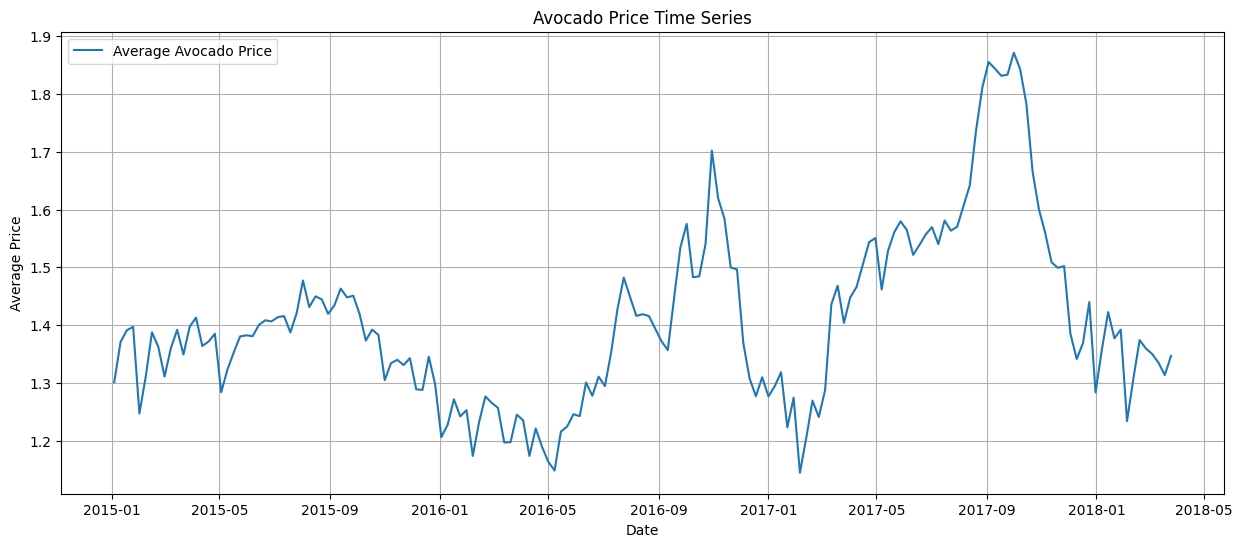

In [6]:
# Cell 5: Part 2 - Time-Series Construction (Using Avocado Data)

# Now that the avocado data is clean, we will construct a time series.
# We'll resample the data to a daily frequency and use linear interpolation
# to fill in any missing values.

print("\n--- Step 2: Time-Series Construction ---")

try:
    # Use the construct_time_series function.
    # We'll aggregate by the mean, resample to daily ('D') frequency,
    # and use linear interpolation.
    ts_avocado = construct_time_series(df_avocado,
                                       dependent_var="value",
                                       freq="D",
                                       agg="mean",
                                       interpolation="linear")

    print(f"Constructed Avocado Time Series Length: {len(ts_avocado)}")
    print("Avocado Time Series head:")
    print(ts_avocado.head())

    # Plot the time series to visualize the data
    plt.figure(figsize=(15, 6))
    plt.plot(ts_avocado.index, ts_avocado.values, label='Average Avocado Price')
    plt.title("Avocado Price Time Series")
    plt.xlabel("Date")
    plt.ylabel("Average Price")
    plt.legend()
    plt.grid(True)
    plt.show()
    
except ValueError as e:
    print(f"Error during time series construction: {e}")

In [7]:
# Cell 6: Part 3 - Vectorization and Storage (Using Avocado Data)

# We will now convert segments of the time series into a vector representation
# and store them in a FAISS index using the TimeSeriesVectorStore class.

print("\n--- Step 3: Vectorization and Storage ---")

# Define parameters for the feature extraction
window_size = 50
stride = 1
fft_components = 20

# Calculate the dimension of the resulting vector
dimension = calculate_embedding_dimension(fft_components)
print(f"Calculated embedding dimension: {dimension}")

# Slice the time series into multiple smaller segments to simulate multiple series
# We will use a sliding window with a large stride to get non-overlapping segments.
segment_length = 200
segments_avocado = [ts_avocado.values[i:i+segment_length] for i in range(0, len(ts_avocado), segment_length) if len(ts_avocado.values[i:i+segment_length]) == segment_length]

if not segments_avocado:
    print("Time series is too short to create segments of the specified length.")
else:
    # Create the vector store
    ts_store = TimeSeriesVectorStore(dimension=dimension)

    # Add the segments to the store. We'll use their slice index as metadata.
    metadata = [{"segment_id": i} for i in range(len(segments_avocado))]
    ts_store.add_time_series(segments_avocado, window_size, stride, fft_components, metadata)

    # Save the index to a file for later use
    ts_store.save_index("ts_index")



--- Step 3: Vectorization and Storage ---
Calculated embedding dimension: 27
Added 5 embeddings to index. Total: 5
Saved index to ts_index.faiss and ts_index.pkl


In [8]:
# Cell 7: Part 4 - Relationship Analysis (Using Avocado Data)

print("\n--- Step 4: Relationship Analysis ---")

# Create a mapping from internal FAISS ID to external ID (our segment ID)
# Make sure we don't exceed the number of vectors in the index
num_vectors = ts_store.index.ntotal
id_map = {i: f"segment_{ts_store.metadata[i]['segment_id']}" for i in range(min(num_vectors, len(ts_store.metadata)))}

print(f"Number of vectors in index: {num_vectors}")
print(f"Number of metadata entries: {len(ts_store.metadata)}")

# Instantiate the RelationshipAnalyzer with our FAISS index and the ID map
analyzer = RelationshipAnalyzer(ts_store.index, id_map)

# Find the top 3 most related segments for each segment using the same metric
top_k = 3
metric = "euclidean"  # Use the same metric for both operations

try:
    results = analyzer.top_k_relationships(k=top_k, metric=metric)
    
    print(f"Top {top_k} related segments for the first 3 segments (using {metric}):")
    for i in range(min(3, len(results))):
        segment_id = f'segment_{i}'
        if segment_id in results:
            print(f"  - {segment_id}: {results[segment_id]}")
        else:
            print(f"  - {segment_id}: Not found in results")
    
    # Build a graph of the relationships using the same metric
    print(f"\nBuilding a similarity graph using {metric}...")
    threshold = 2.0 if metric == "euclidean" else 0.7
    G = analyzer.build_graph(metric=metric, threshold=threshold)
    print(f"Graph created with {G.number_of_nodes()} nodes and {G.number_of_edges()} edges.")
    
    # Additional analysis: Check connectivity of the graph
    if G.number_of_nodes() > 0:
        print(f"Graph is connected: {nx.is_connected(G)}")
        if not nx.is_connected(G):
            components = nx.number_connected_components(G)
            print(f"Number of connected components: {components}")
            
            # Get the size of the largest component
            largest_component = max(nx.connected_components(G), key=len)
            print(f"Largest component size: {len(largest_component)}")
            
        # Calculate average degree of connectivity
        degrees = [deg for _, deg in G.degree()]
        print(f"Average degree: {sum(degrees) / len(degrees):.2f}")
        
        # Calculate average edge weight
        if G.number_of_edges() > 0:
            weights = [data['weight'] for _, _, data in G.edges(data=True)]
            if metric == "cosine":
                print(f"Average similarity: {sum(weights) / len(weights):.3f}")
            else:
                print(f"Average distance: {sum(weights) / len(weights):.3f}")
                
except Exception as e:
    print(f"Error during relationship analysis: {e}")
    import traceback
    traceback.print_exc()


--- Step 4: Relationship Analysis ---
Number of vectors in index: 5
Number of metadata entries: 5
Top 3 related segments for the first 3 segments (using euclidean):
  - segment_0: [('segment_1', np.float32(0.4658115)), ('segment_2', np.float32(0.8924497)), ('segment_4', np.float32(0.912874))]
  - segment_1: [('segment_0', np.float32(0.4658115)), ('segment_2', np.float32(0.5378823)), ('segment_4', np.float32(0.7274962))]
  - segment_2: [('segment_1', np.float32(0.5378823)), ('segment_4', np.float32(0.7639613)), ('segment_0', np.float32(0.8924497))]

Building a similarity graph using euclidean...
Graph created with 5 nodes and 10 edges.
Graph is connected: True
Average degree: 4.00
Average distance: 0.932
